In [1]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.2  # Node power consumption in W
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/Quito.csv"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from visualization import (
    get_config_trace,
    plot_soc,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc,
    plot_full_soc_analysis,
    plot_pareto_front,
)


## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability
6. Compute Optimal solutions (Pareto Front)
7. Compute scores of the solutions in Pareto front

In [3]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!


## Design space

In [4]:
df_design = simulator.build_design_space()
df_design

,panel_area_m2,battery_capacity_Ah,eta_PMU
0,0.000100,0.011,0.70
1,0.000100,0.011,0.75
2,0.000100,0.011,0.80
3,0.000100,0.011,0.85
4,0.000100,0.011,0.87
...,...,...,...
3339,0.061102,3.200,0.85
3340,0.061102,3.200,0.87
3341,0.061102,3.200,0.90
3342,0.061102,3.200,0.95


In [5]:
## Explore Results

In [6]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
0,0.010000,1.8,0.98,8760,0,1743,0.809293,0.155338,272.685615,501.871336,8760,0,3.6,0.371726,0.0,0.198973,-229.185721,0.601889
1,0.010057,1.8,0.98,8760,0,1759,0.810092,0.155067,272.590549,505.792991,8760,0,3.6,0.374146,0.0,0.200799,-233.202442,0.600203
2,0.010000,2.0,0.95,8760,0,1534,0.812643,0.148389,281.846990,466.112423,8760,0,2.0,0.347743,0.0,0.175114,-184.265433,0.598064
3,0.010057,2.0,0.95,8760,0,1558,0.813648,0.147860,281.744303,469.790773,8760,0,2.0,0.350018,0.0,0.177854,-188.046470,0.595695
4,0.010000,2.0,0.98,8760,0,1743,0.828364,0.139804,272.685615,501.871336,8760,0,2.0,0.371726,0.0,0.198973,-229.185721,0.580246
5,0.016000,1.1,0.95,8760,0,2496,0.725949,0.252617,274.616544,856.536957,8760,0,2.0,0.587200,0.0,0.284932,-581.920413,0.579502
6,0.010057,2.0,0.98,8760,0,1759,0.829083,0.139561,272.590549,505.792991,8760,0,2.0,0.374146,0.0,0.200799,-233.202442,0.578560
7,0.016000,1.1,0.98,8760,0,2584,0.739021,0.244502,265.794066,917.669081,8760,0,2.0,0.626545,0.0,0.294977,-651.875016,0.572000
8,0.016000,1.2,0.95,8760,0,2496,0.748786,0.231566,274.616544,856.536957,8760,0,1.2,0.587200,0.0,0.284932,-581.920413,0.568681
9,0.010000,2.3,0.95,8760,0,1534,0.837081,0.129034,281.846990,466.112423,8760,0,46.0,0.347743,0.0,0.175114,-184.265433,0.565599


## Best combinations

In [7]:
print(summary["score"].max())
best_configs = summary[summary["score"] == summary["score"].max()]

print(len(best_configs))

for config_idx, config_row in best_configs.iterrows():
    print()
    print(config_row[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

0.6018891610438082
1

panel_area_m2    0.010000
C_batt_Ah        1.800000
eta_PMU          0.980000
score            0.601889
Name: 0, dtype: float64


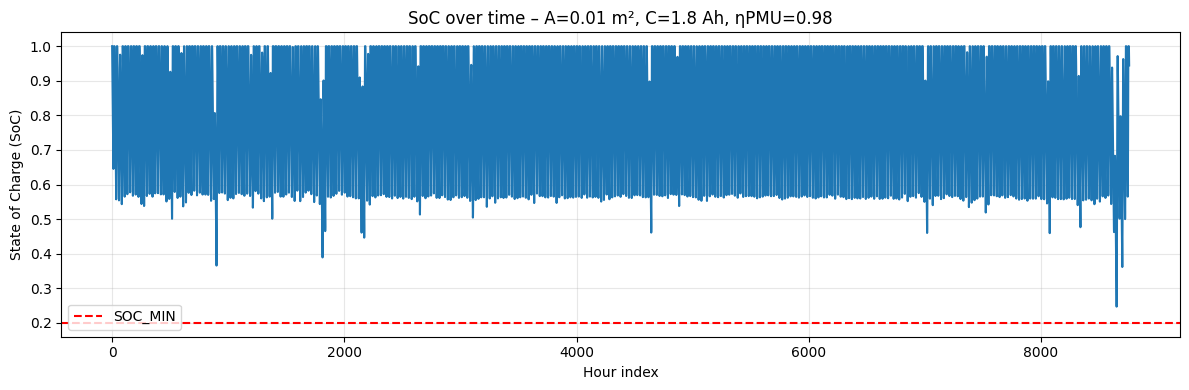

In [8]:
for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_Ah']} Ah, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

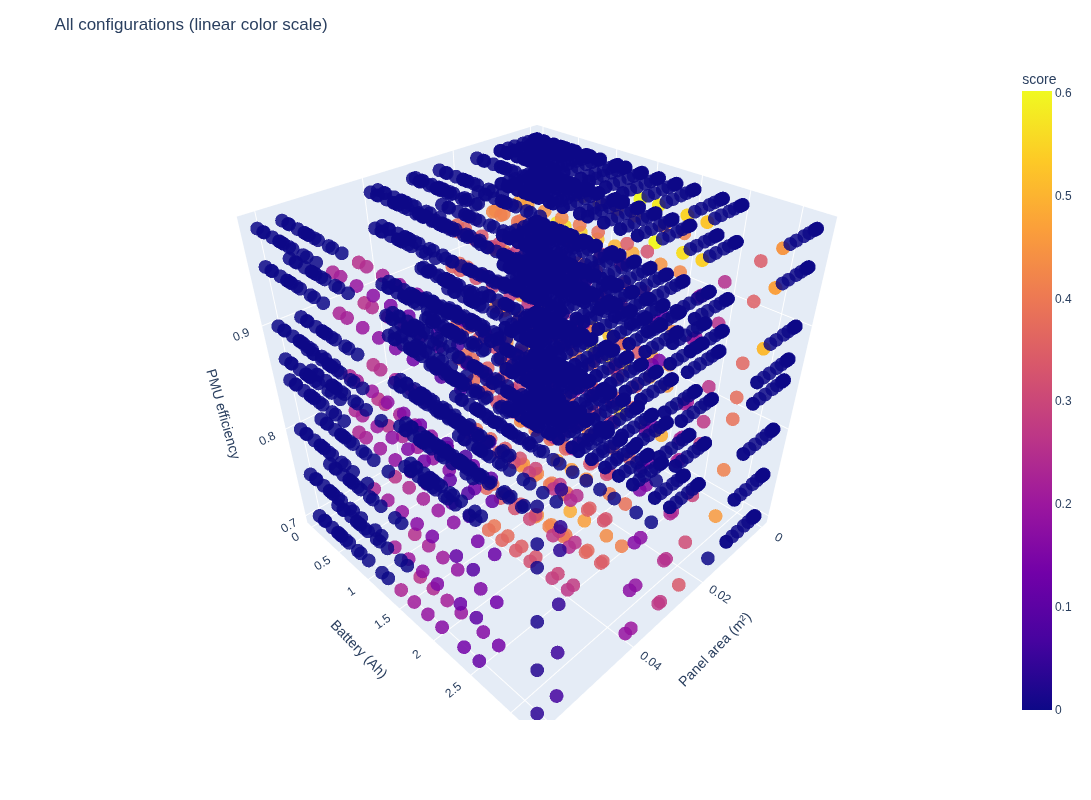

In [9]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_Ah",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_Ah": "Battery (Ah)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

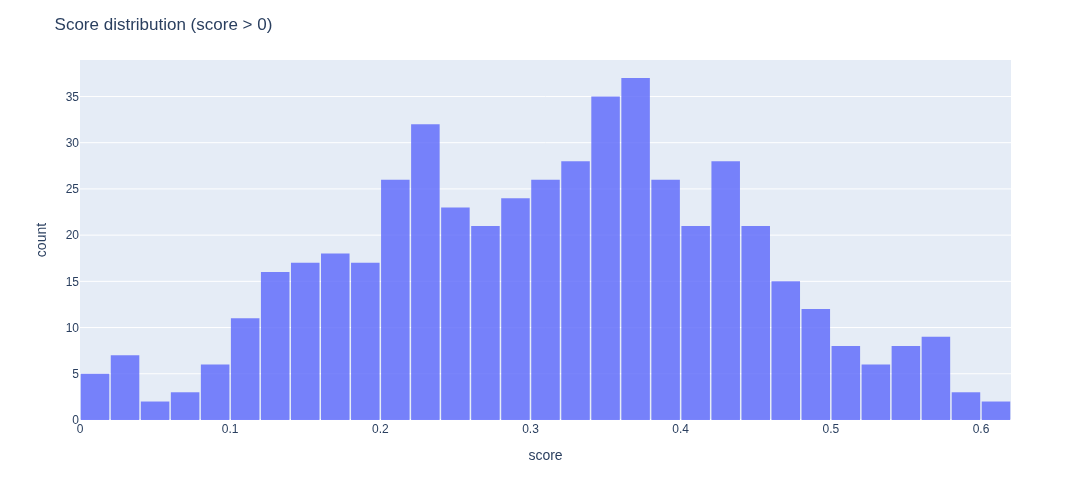

In [10]:
summary_plot = summary[summary["score"] > 0].copy()

fig = px.histogram(
    summary_plot,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution (score > 0)",
    bargap=0.05
)

fig.show()

## Score at Maximum PMU Efficiency (not best configs)

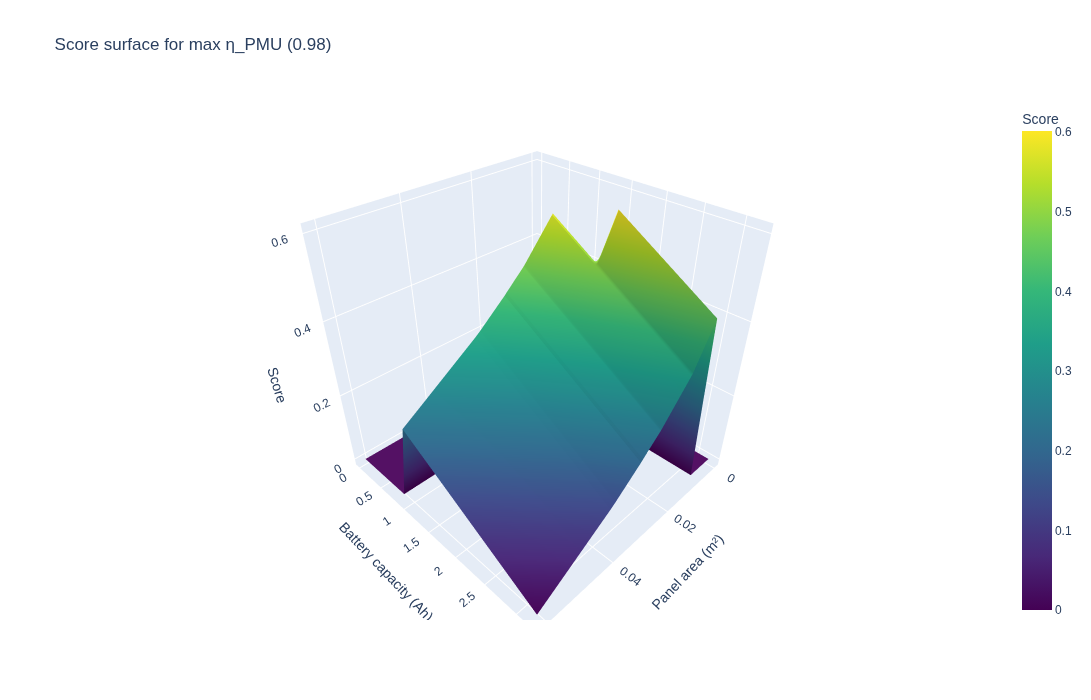

In [11]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_Ah",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (Ah)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Summary statistics

In [12]:
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")
print(f"Viable configurations (score > 0): {len(summary[summary['score'] > 0])}")
print(f"Configurations with failures: {len(summary[summary['failure_hours'] > 0])}")
print("Configuration with I_req_max > I_batt_max):",
      len(summary[summary["I_req_max_A"] > summary["I_batt_max_A"]]))



=== Simulation Summary ===
Total configurations evaluated: 3344
Best score achieved: 0.6019
Configurations with best score: 1
Viable configurations (score > 0): 513
Configurations with failures: 2830
Configuration with I_req_max > I_batt_max): 837


## Invalidad configs due to < SoC_min

In [13]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_Ah,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
1244,0.000100,0.011,0.87,8760,1,0.011,0.062131
1247,0.000100,0.011,0.98,8760,1,0.011,0.055157
2085,0.001000,0.011,0.85,8760,1,0.011,0.063593
1246,0.000100,0.011,0.95,8760,1,0.011,0.056899
2084,0.001000,0.011,0.80,8760,1,0.011,0.067568
...,...,...,...,...,...,...,...
1605,0.031000,1.200,0.80,1,5532,1.200,0.834101
1602,0.031000,1.100,0.87,1,5532,2.000,0.990570
1487,0.030414,1.100,0.87,1,5532,2.000,0.970956
636,0.025000,1.400,0.75,1,8651,2.000,0.581317


## Invalid configs due I_req > I_batt_max

In [14]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_Ah,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
473,0.061102,2.000,0.98,2.542020,2.000,0,8760
497,0.061102,2.500,0.98,2.542020,1.500,0,8760
1209,0.061102,0.550,0.98,2.542020,1.000,2149,19
416,0.061102,1.400,0.98,2.542020,2.000,0,8760
1201,0.061102,0.500,0.98,2.542020,0.500,2377,18
...,...,...,...,...,...,...,...
1247,0.000100,0.011,0.98,0.055157,0.011,8760,1
1796,0.000625,0.011,0.98,0.055157,0.011,8760,1
2309,0.000400,0.011,0.98,0.055157,0.011,8760,1
2089,0.001000,0.011,0.98,0.055157,0.011,8760,1


In [15]:
summary["autonomy_hours"].describe()


count    3344.000000
mean     1527.807117
std      3233.272723
min         1.000000
25%        12.000000
50%        17.000000
75%        44.250000
max      8760.000000
Name: autonomy_hours, dtype: float64

In [16]:
summary.sort_values("autonomy_hours").head(5)


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
1860,0.000625,0.011,0.95,8760,8759,1,0.200091,0.008547,452.619256,-0.0,1,8760,0.011,0.056899,0.999886,0.000114,452.619256,0.0
2354,0.000400,0.011,0.70,8760,8759,1,0.200091,0.008547,647.125623,-0.0,1,8760,0.011,0.077220,0.999886,0.000114,647.125623,0.0
2342,0.000400,0.011,0.75,8760,8759,1,0.200091,0.008547,602.029098,-0.0,1,8760,0.011,0.072072,0.999886,0.000114,602.029098,0.0
2308,0.000400,0.011,0.95,8760,8759,1,0.200091,0.008547,469.113024,-0.0,1,8760,0.011,0.056899,0.999886,0.000114,469.113024,0.0
2309,0.000400,0.011,0.98,8760,8759,1,0.200091,0.008547,453.854801,-0.0,1,8760,0.011,0.055157,0.999886,0.000114,453.854801,0.0


In [17]:
summary.sort_values("autonomy_hours").tail(5)

,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
19,0.010000,2.5,0.95,8760,0,1534,0.850114,0.118711,281.846990,466.112423,8760,0,1.5,0.347743,0.0,0.175114,-184.265433,0.543956
18,0.016000,2.0,0.80,8760,0,1748,0.794490,0.167251,329.038501,582.423528,8760,0,2.0,0.409580,0.0,0.199543,-253.385027,0.545877
17,0.010057,2.3,0.98,8760,0,1759,0.851376,0.121357,272.590549,505.792991,8760,0,46.0,0.374146,0.0,0.200799,-233.202442,0.546095
16,0.016000,1.4,0.95,8760,0,2496,0.784674,0.198485,274.616544,856.536957,8760,0,2.0,0.587200,0.0,0.284932,-581.920413,0.547038
15,0.010000,2.3,0.98,8760,0,1743,0.850751,0.121569,272.685615,501.871336,8760,0,46.0,0.371726,0.0,0.198973,-229.185721,0.547782


In [18]:
# 1) Maximum score configuration
cfg_best = summary.sort_values("score", ascending=False).iloc[0]

# 2) Minimum non-zero score configuration
summary_nonzero = summary[summary["score"] > 0]
cfg_bad = summary_nonzero.sort_values("score", ascending=True).iloc[0]

# 3) Score closest to 0.5 (mid-score representative)
target = 0.5
idx_mid = (summary["score"] - target).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

# 4) Failure case (for comparison)
cfg_fail = summary[summary["score"] == 0].sort_values("score").iloc[0]


print("\n=== BEST SCORE CONFIGURATION ===")
print(cfg_best[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== BAD NON-ZERO SCORE CONFIGURATION ===")
print(cfg_bad[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== MID-SCORE (~0.5) CONFIGURATION ===")
print(cfg_mid[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== FAILURE CASE CONFIGURATION ===")
print(cfg_fail[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])



=== BEST SCORE CONFIGURATION ===
panel_area_m2    0.010000
C_batt_Ah        1.800000
eta_PMU          0.980000
score            0.601889
Name: 0, dtype: float64

=== BAD NON-ZERO SCORE CONFIGURATION ===
panel_area_m2    0.061102
C_batt_Ah        3.200000
eta_PMU          0.950000
score            0.002387
Name: 512, dtype: float64

=== MID-SCORE (~0.5) CONFIGURATION ===
panel_area_m2    0.016000
C_batt_Ah        2.000000
eta_PMU          0.900000
score            0.496772
Name: 36, dtype: float64

=== FAILURE CASE CONFIGURATION ===
panel_area_m2    0.016
C_batt_Ah        2.300
eta_PMU          0.700
score            0.000
Name: 513, dtype: float64


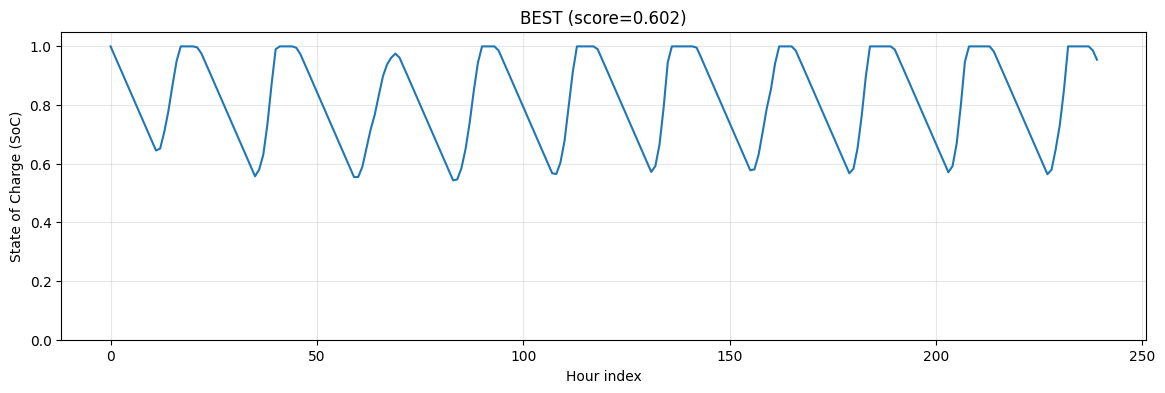

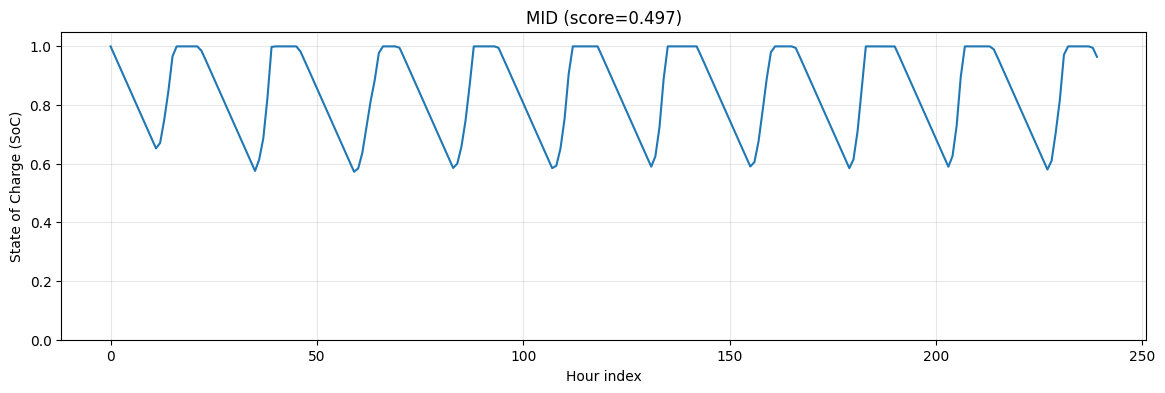

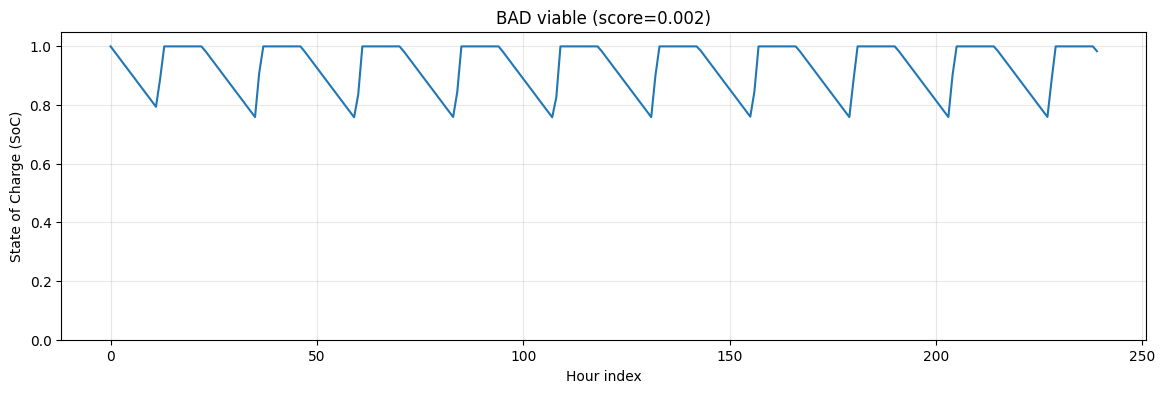

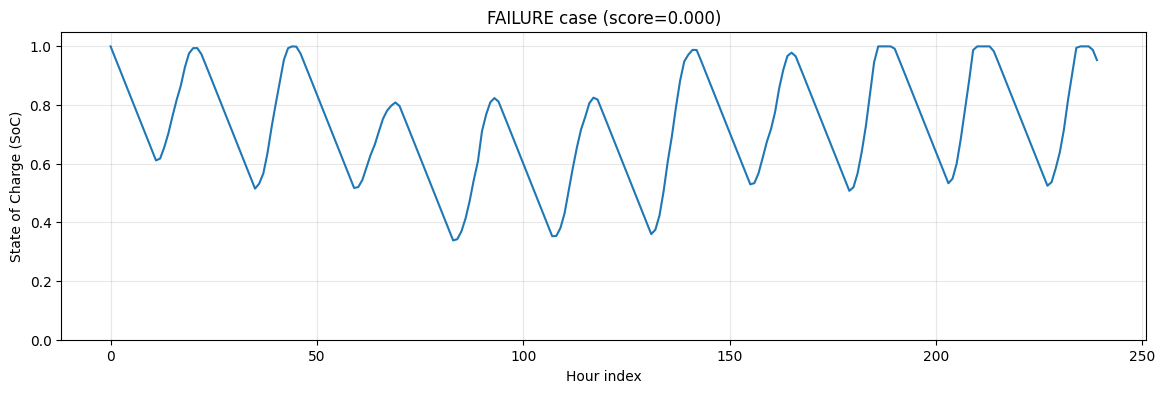

In [19]:
# BEST SCORE
plot_soc(
    df_soc,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    title=f"BEST (score={cfg_best['score']:.3f})"
)

# MID SCORE (~0.5)
plot_soc(
    df_soc,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    title=f"MID (score={cfg_mid['score']:.3f})"
)

# BAD NON-ZERO SCORE
plot_soc(
    df_soc,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    title=f"BAD viable (score={cfg_bad['score']:.3f})"
)

# FAILURE CASE
plot_soc(
    df_soc,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    title=f"FAILURE case (score={cfg_fail['score']:.3f})"
)

In [20]:
from visualization import (
    get_config_trace,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc
)


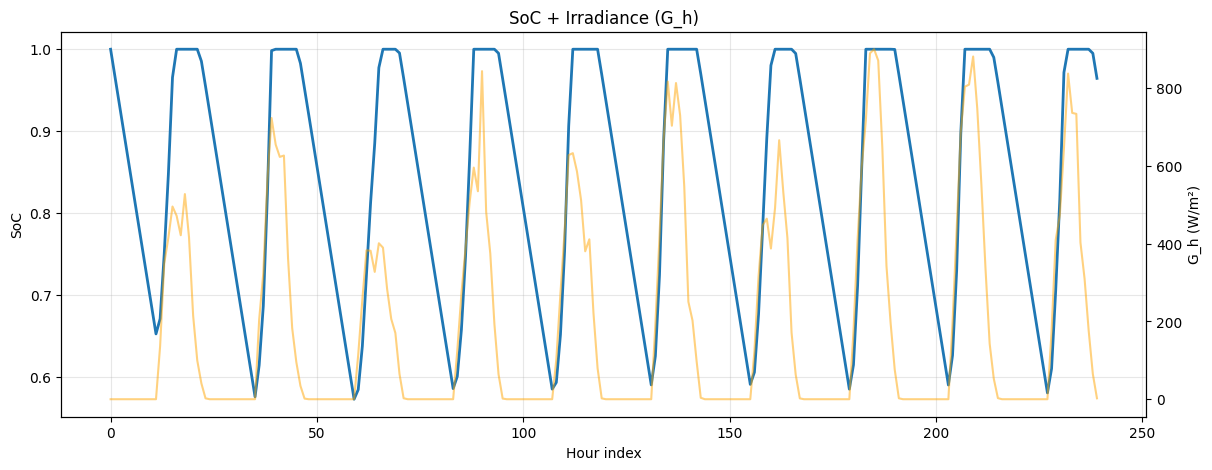

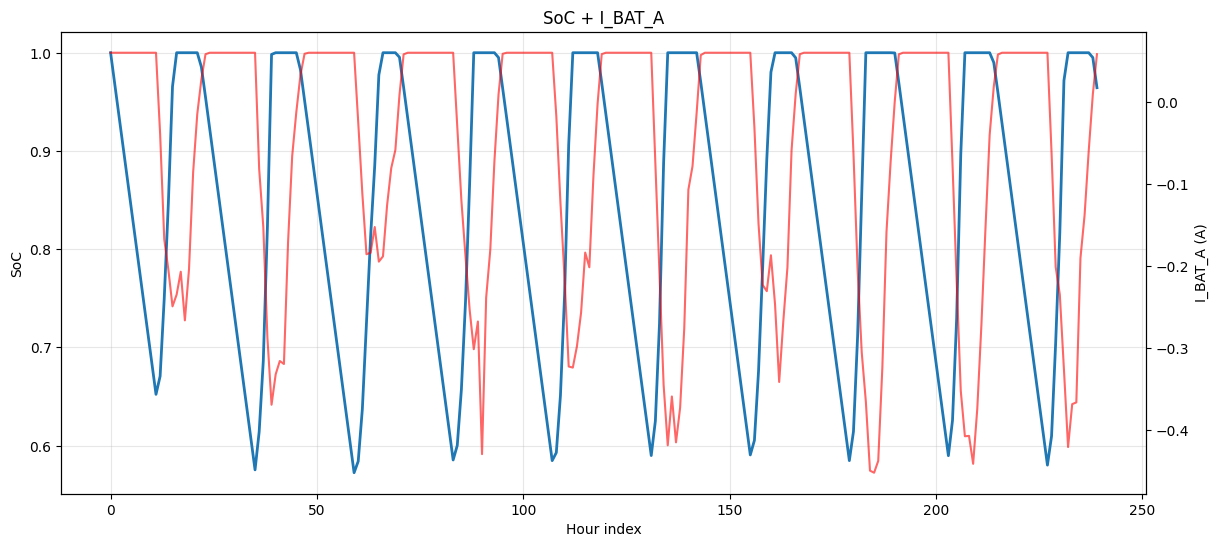

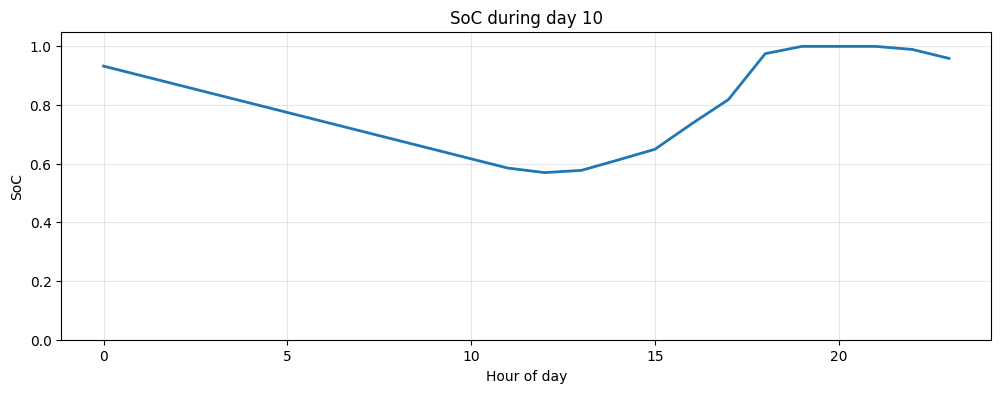

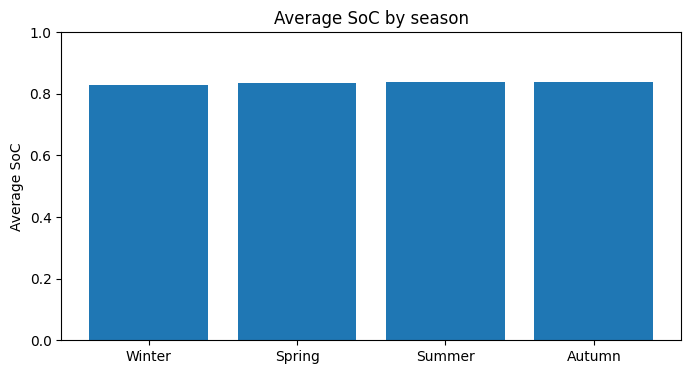

In [21]:
# Choose a configuration, e.g. cfg_mid (score ~0.5)
panel  = cfg_mid["panel_area_m2"]
cap    = cfg_mid["C_batt_Ah"]
eta    = cfg_mid["eta_PMU"]

cfg = get_config_trace(df_soc, panel, cap, eta)

plot_soc_gh(cfg, df_pv, hours=240, title="SoC + Irradiance (G_h)")
plot_soc_ibatt(cfg, hours=240, title="SoC + I_BAT_A")
plot_daily(cfg, day_index=10)
plot_seasonal_soc(cfg)


In [22]:
# Sort all configurations by score
summary_sorted = summary.sort_values("score", ascending=False)

# 1) Best score
cfg_best = summary_sorted.iloc[0]
title_best = f"BEST - Panel: {cfg_best['panel_area_m2']} m², Batería: {cfg_best['C_batt_Ah']} Ah, PMU: {cfg_best['eta_PMU']}, Score: {cfg_best['score']:.3f}"

# 2) BAD non-zero score
cfg_bad = summary_sorted[summary_sorted["score"] > 0].sort_values("score").iloc[0]
title_bad = f"BAD - Panel: {cfg_bad['panel_area_m2']} m², Batería: {cfg_bad['C_batt_Ah']} Ah, PMU: {cfg_bad['eta_PMU']}, Score: {cfg_bad['score']:.3f}"

# 3) MID score (between BAD and BEST)
configs_between = summary_sorted[
    (summary_sorted["score"] > cfg_bad["score"]) &
    (summary_sorted["score"] < cfg_best["score"])
].sort_values("score")
cfg_mid = configs_between.iloc[len(configs_between) // 2]
title_mid = f"MID - Panel: {cfg_mid['panel_area_m2']} m², Batería: {cfg_mid['C_batt_Ah']} Ah, PMU: {cfg_mid['eta_PMU']}, Score: {cfg_mid['score']:.3f}"

# 4) Failure case (for comparison)
cfg_fail = summary_sorted[summary_sorted["score"] == 0].sort_values("score").iloc[0]
title_fail = f"FAIL - Panel: {cfg_fail['panel_area_m2']} m², Batería: {cfg_fail['C_batt_Ah']} Ah, PMU: {cfg_fail['eta_PMU']}, Score: {cfg_fail['score']:.3f}"

print("\nBEST:", cfg_best[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nMID:", cfg_mid[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nBAD:", cfg_bad[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nFAIL:", cfg_fail[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])



BEST: panel_area_m2    0.010000
C_batt_Ah        1.800000
eta_PMU          0.980000
score            0.601889
Name: 0, dtype: float64

MID: panel_area_m2    0.030414
C_batt_Ah        2.300000
eta_PMU          0.850000
score            0.323686
Name: 256, dtype: float64

BAD: panel_area_m2    0.061102
C_batt_Ah        3.200000
eta_PMU          0.950000
score            0.002387
Name: 512, dtype: float64

FAIL: panel_area_m2    0.016
C_batt_Ah        2.300
eta_PMU          0.700
score            0.000
Name: 513, dtype: float64


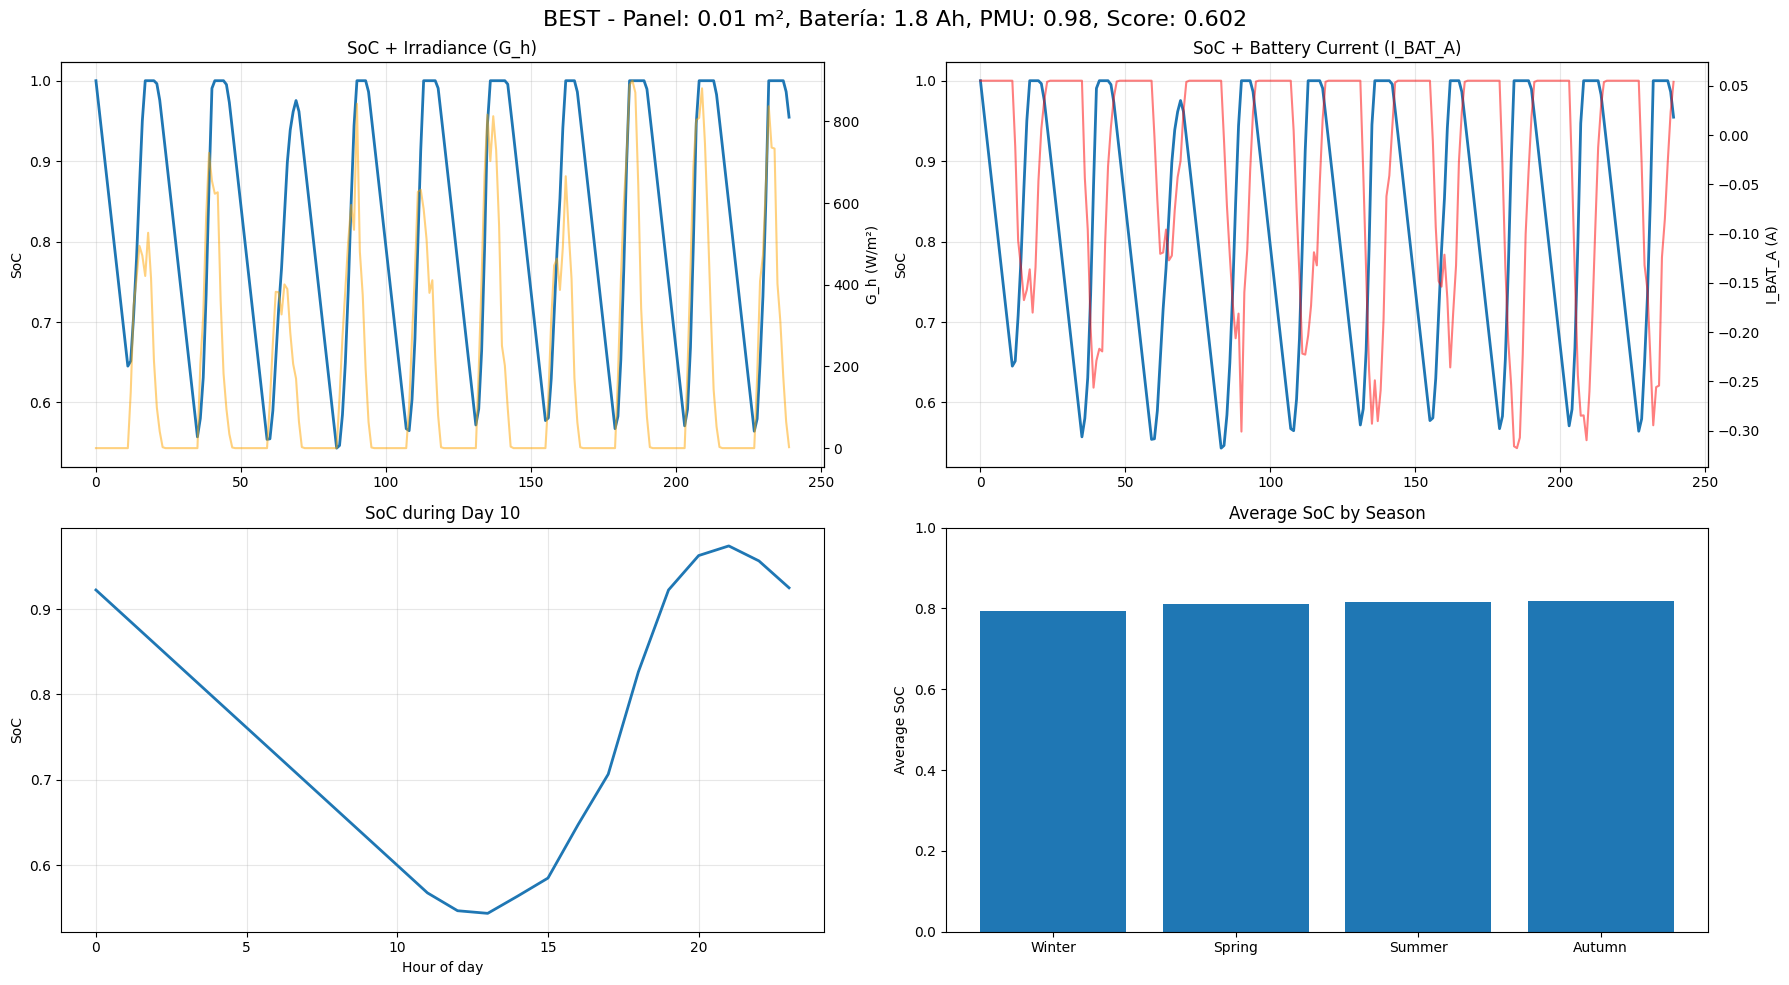

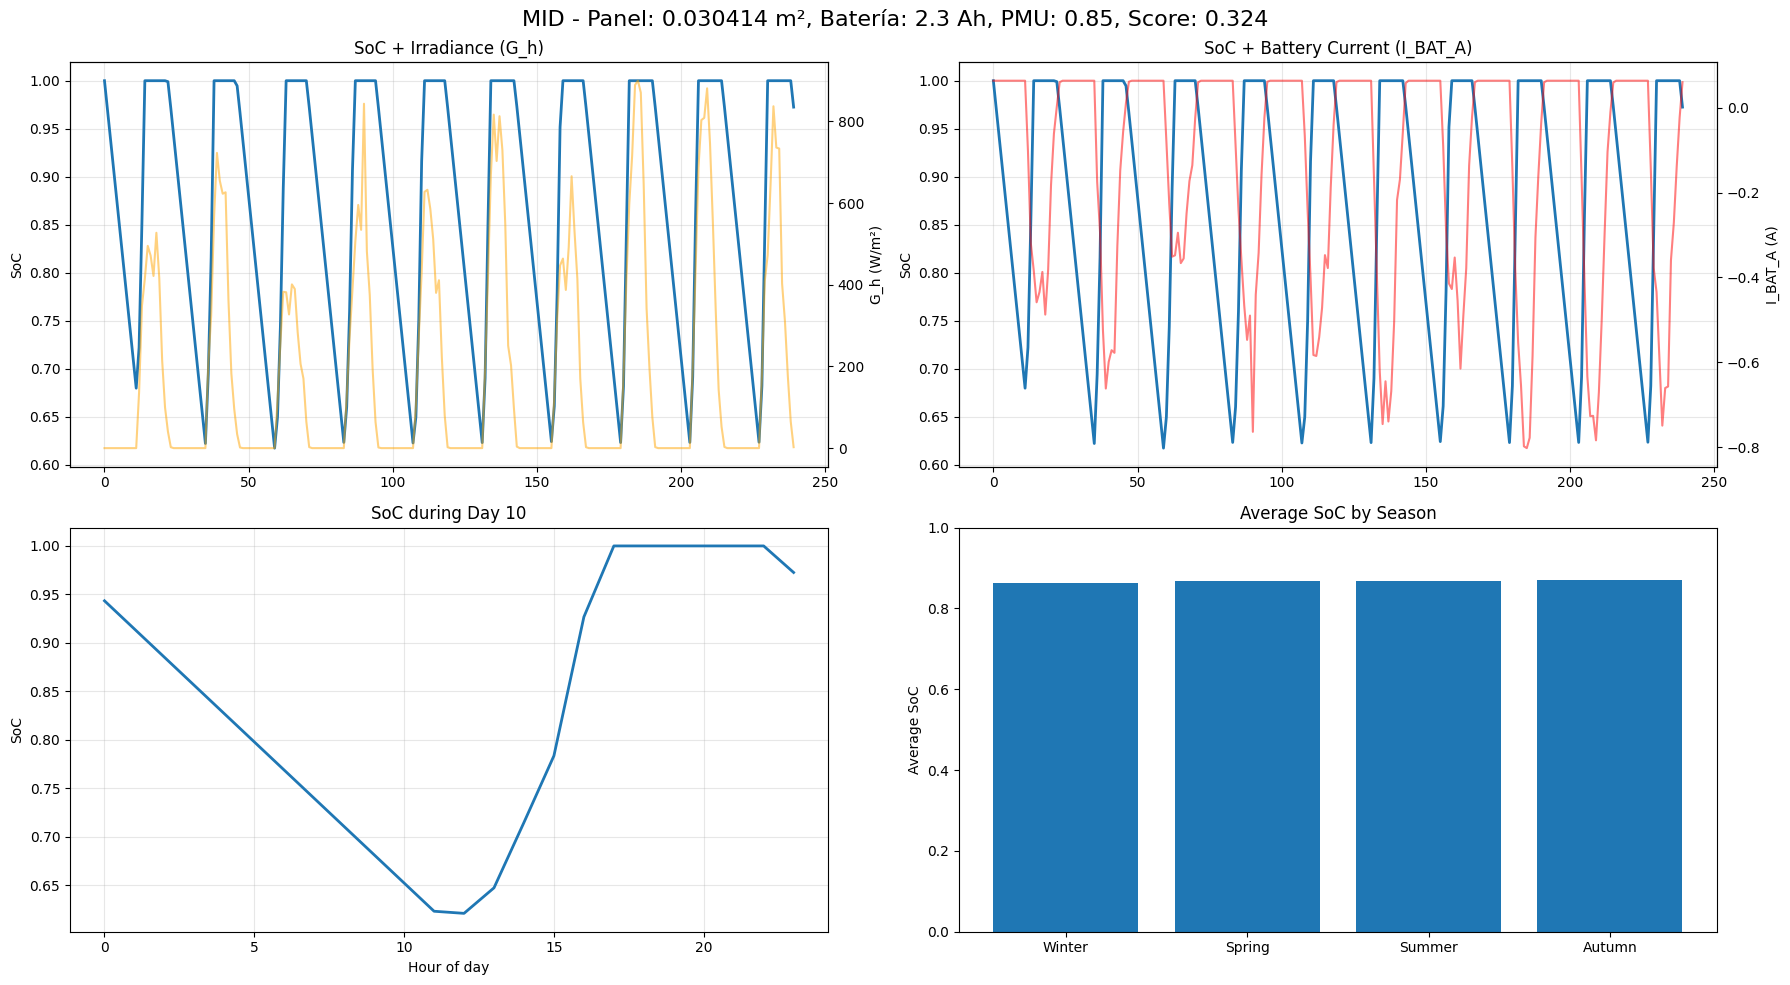

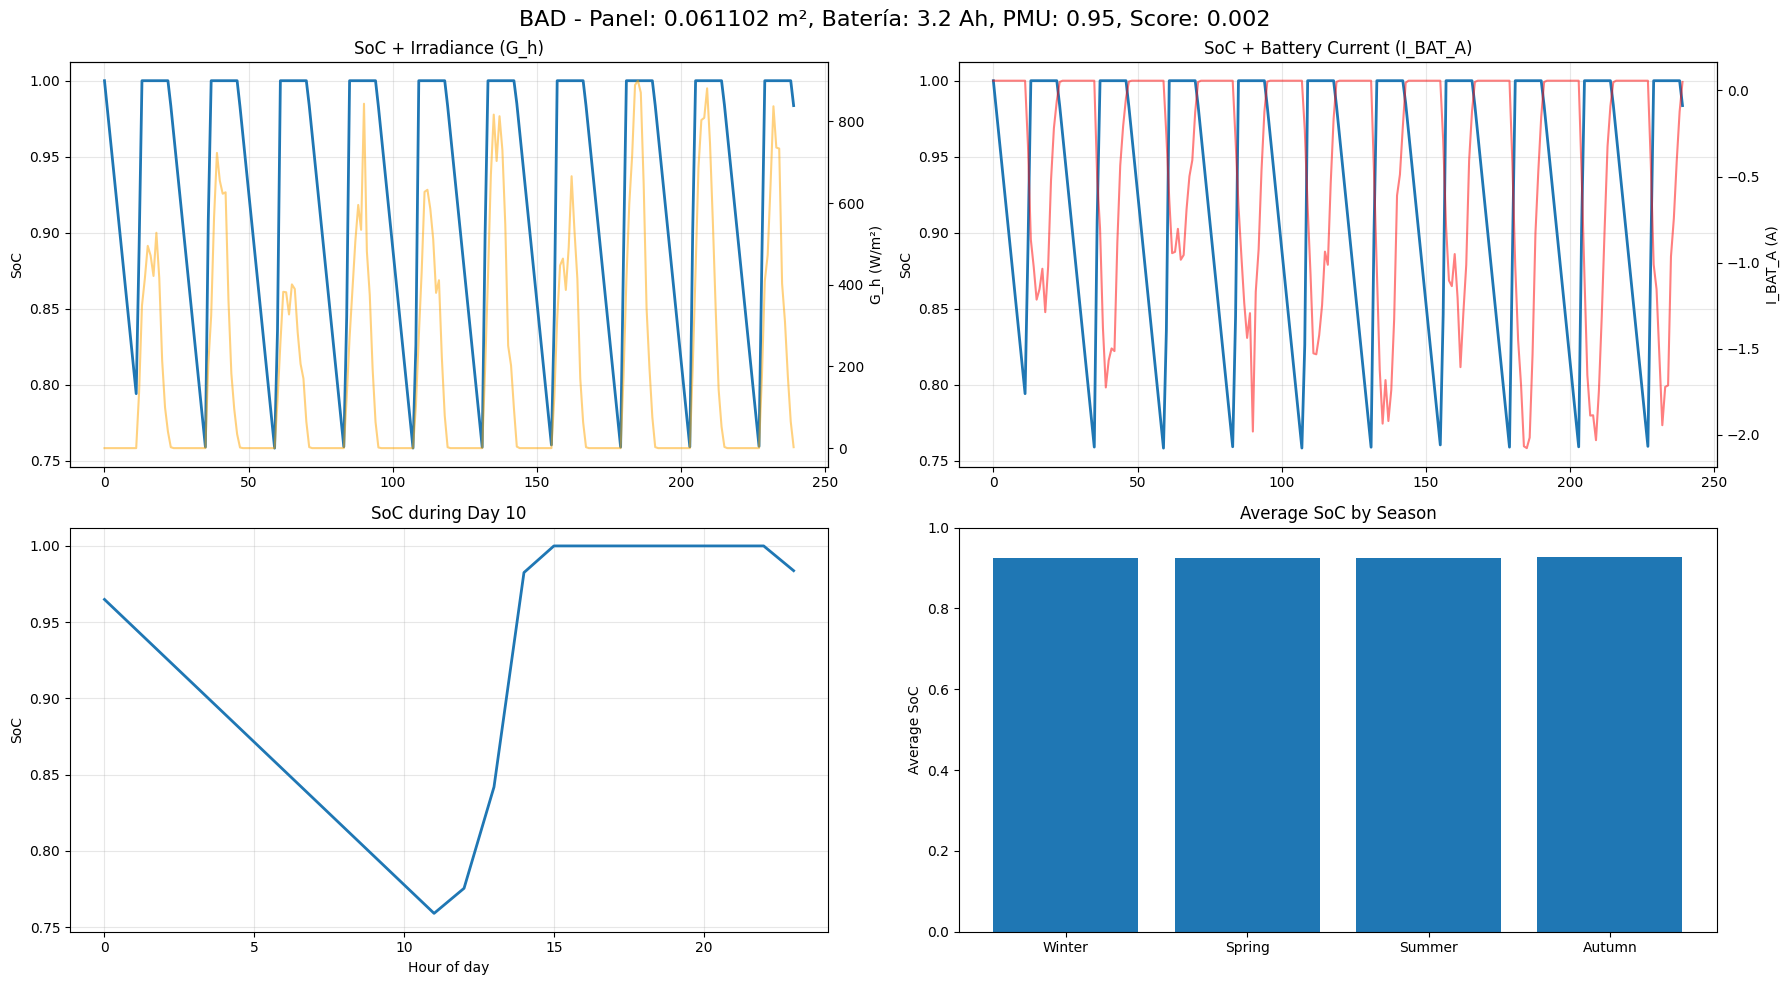

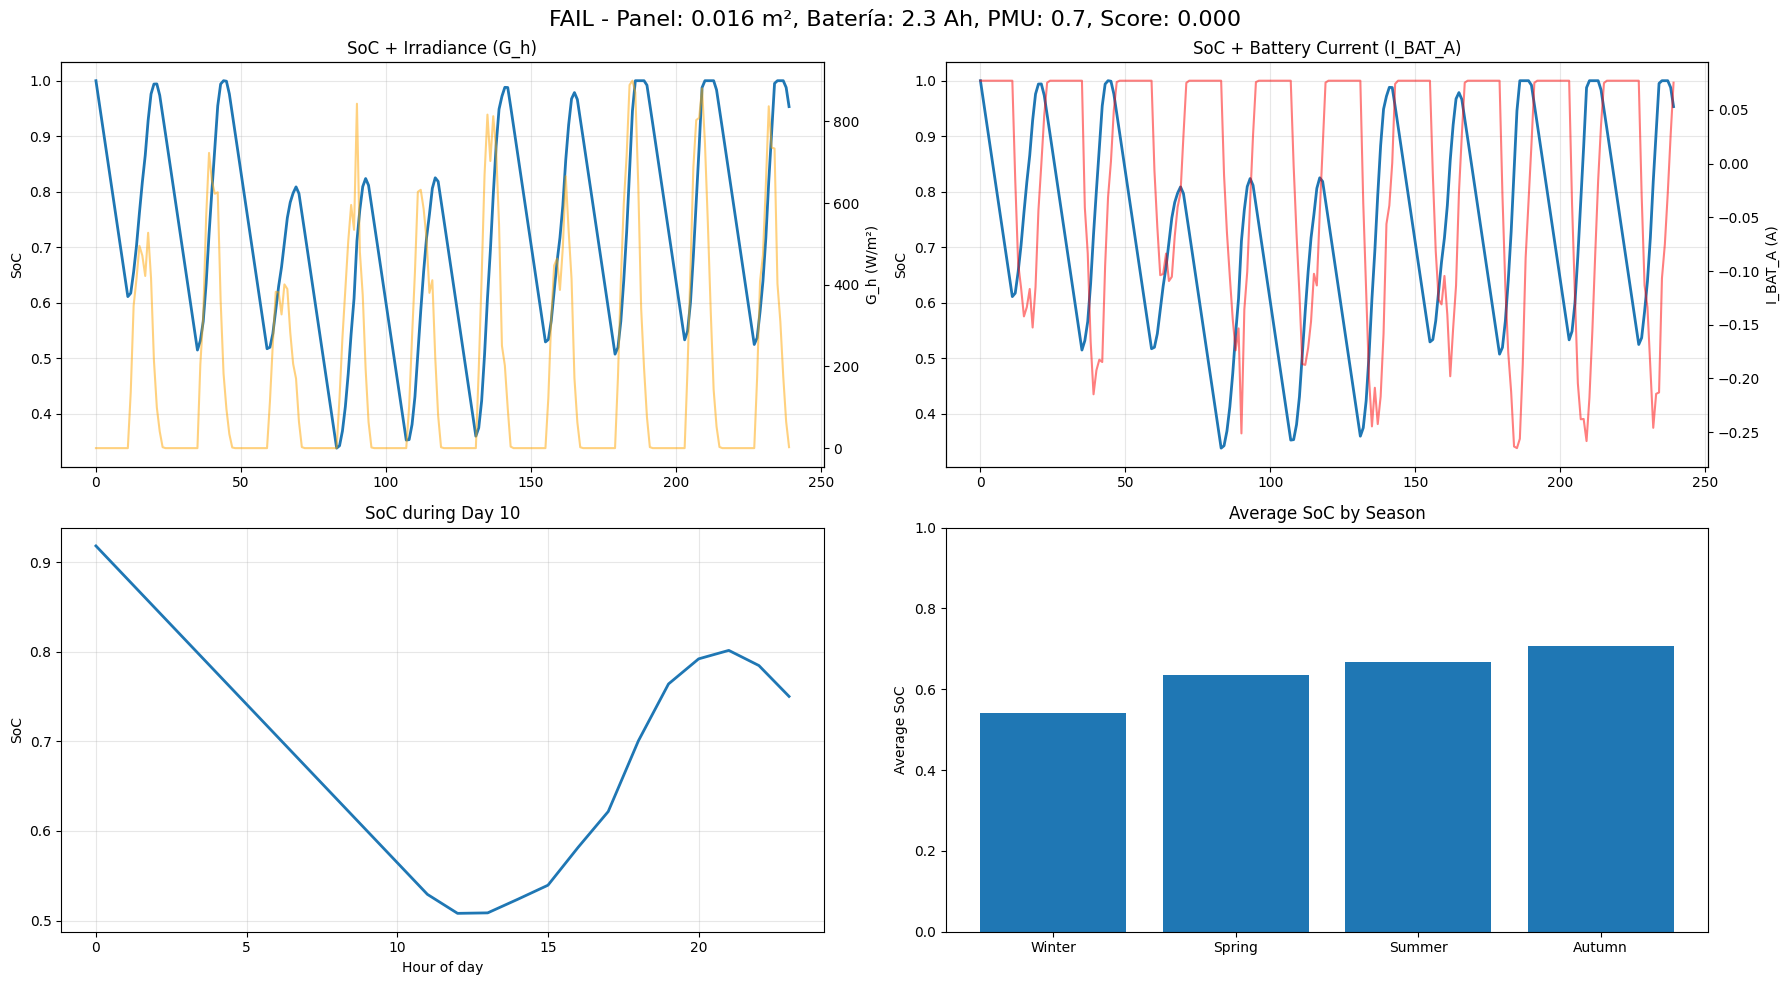

In [23]:
# === BEST SCORE ===
plot_full_soc_analysis(
    title_best,
    df_soc, df_pv,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    hours=240,
    day_index=10
)

# === MID-SCORE (~0.5) ===
plot_full_soc_analysis(
    title_mid,
    df_soc, df_pv,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    hours=240,
    day_index=10
)

# === BAD NON-ZERO SCORE ===
plot_full_soc_analysis(
    title_bad,
    df_soc, df_pv,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    hours=240,
    day_index=10
)

# === FAILURE CASE ===
plot_full_soc_analysis(
    title_fail,
    df_soc, df_pv,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    hours=240,
    day_index=10
)


## Pareto front

In [24]:
# ── Compute Pareto front ────────────────────────────────────────────────────
pareto_objectives = [
    ("C_batt_Ah",        -1),
    ("panel_area_m2",    -1),
    ("soc_full_fraction", -1),
]

front = simulator.pareto_front(summary, pareto_objectives)

print(f"{len(front)} configurations on the Pareto front (out of "
      f"{(summary['failure_hours'] == 0).sum()} viable ones)\n")

for i, row in front.iterrows():
    print(f"--- Config #{i} ---")
    print(f"  Panel area  : {row['panel_area_m2']*1e4:.1f} cm²  ({row['panel_area_m2']} m²)")
    print(f"  Battery     : {row['C_batt_Ah']} Ah")
    print(f"  η_PMU       : {row['eta_PMU']}")
    print(f"  SoC full    : {row['soc_full_fraction']*100:.1f}%")
    print(f"  Autonomy    : {row['autonomy_hours']} h")
    print(f"  Failures    : {int(row['failure_hours'])} h")
    print()


6 configurations on the Pareto front (out of 514 viable ones)

--- Config #0 ---
  Panel area  : 160.0 cm²  (0.016 m²)
  Battery     : 1.1 Ah
  η_PMU       : 0.95
  SoC full    : 28.5%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #1 ---
  Panel area  : 160.0 cm²  (0.016 m²)
  Battery     : 1.4 Ah
  η_PMU       : 0.9
  SoC full    : 26.5%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #2 ---
  Panel area  : 160.0 cm²  (0.016 m²)
  Battery     : 1.6 Ah
  η_PMU       : 0.85
  SoC full    : 23.7%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #3 ---
  Panel area  : 100.0 cm²  (0.01 m²)
  Battery     : 1.8 Ah
  η_PMU       : 0.98
  SoC full    : 19.9%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #4 ---
  Panel area  : 100.0 cm²  (0.01 m²)
  Battery     : 2.0 Ah
  η_PMU       : 0.95
  SoC full    : 17.5%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #5 ---
  Panel area  : 100.0 cm²  (0.01 m²)
  Battery     : 3.2 Ah
  η_PMU       : 0.9
  

# Compute score from Pareto front¶
Pareto front¶

In [25]:
score_objectives = [
    ("surplus_Ah",        -1),
    ("eta_PMU",           +1),
    ("soc_std",           -1),
]

score = simulator.compute_score(front, score_objectives)

# columnas a mostrar
cols = [
    "panel_area_m2",
    "C_batt_Ah",
    "soc_full_fraction",
    "eta_PMU",
    "soc_mean",
    "soc_std",
    "surplus_Ah",
    "deficit_Ah",
    "hours_soc_full",
    "score"
]

tabla = score[cols]

# función para formatear valores
def fmt(v):
    if isinstance(v, float):
        return f"{v:.5f}"
    return str(v)

# calcular ancho máximo de cada columna
widths = []
for col in tabla.columns:
    max_data = tabla[col].map(fmt).map(len).max()
    widths.append(max(max_data, len(col)))

# encabezado
header = "  ".join(col.ljust(w) for col, w in zip(tabla.columns, widths))
print(header)

# línea separadora
print("-" * len(header))

# filas
for _, row in tabla.iterrows():
    line = "  ".join(fmt(v).ljust(w) for v, w in zip(row, widths))
    print(line)


panel_area_m2  C_batt_Ah  soc_full_fraction  eta_PMU  soc_mean  soc_std  surplus_Ah  deficit_Ah  hours_soc_full  score  
------------------------------------------------------------------------------------------------------------------------
0.01000        1.80000    0.19897            0.98000  0.80929   0.15534  272.68561   501.87134   1743.00000      1.00000
0.01000        2.00000    0.17511            0.95000  0.81264   0.14839  281.84699   466.11242   1534.00000      0.81077
0.01600        1.10000    0.28493            0.95000  0.72595   0.25262  274.61654   856.53696   2496.00000      0.56338
0.01000        3.20000    0.11975            0.90000  0.85047   0.11694  298.55022   409.43915   1049.00000      0.54185
0.01600        1.40000    0.26530            0.90000  0.76496   0.21014  290.67224   759.32337   2324.00000      0.33775
0.01600        1.60000    0.23733            0.85000  0.77304   0.19516  308.68952   667.95483   2079.00000      0.00000


# Visualize SOC through year

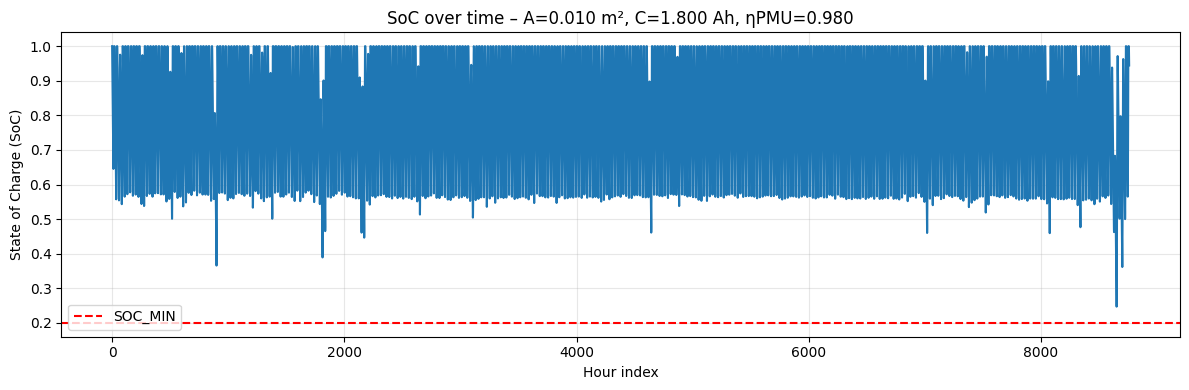

In [26]:
cfg = score.iloc[0]   # primera fila del DataFrame

plt.figure(figsize=(12, 4))
plt.plot(config_soc['hour_index'], config_soc['SoC'])

plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')

plt.xlabel('Hour index')
plt.ylabel('State of Charge (SoC)')
plt.title(
    f"SoC over time – A={cfg['panel_area_m2']:.3f} m², "
    f"C={cfg['C_batt_Ah']:.3f} Ah, ηPMU={cfg['eta_PMU']:.3f}"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()